<a href="https://colab.research.google.com/github/albert-magarire/Leetcode-Solutions/blob/java-dsa/MATH213_json.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ultimate Movie Poster Analysis Notebook

**Merged from:** `Albert_Magarire_MATH_213_Final.ipynb` and `can-we-judge-a-movie-by-it-s-poster.ipynb`.

### Objective
This notebook investigates if Deep Learning can find correlations between a movie's poster and its associated Genre or IMDB Score.

### Workflow
1.  **Data Acquisition**: Download metadata and poster URLs.
2.  **Image Downloading**: Fetch the actual images from the web (includes a limit for demonstration speed).
3.  **EDA**: Visualize IMDB score distributions and Genre counts.
4.  **Approach 1 (Keras)**: Build a Custom CNN from scratch for Regression.
5.  **Approach 2 (FastAI)**: Use Transfer Learning (ResNet) for Regression and Classification.
6.  **Evaluation**: Compare predictions vs. ground truth.

## 1. Imports and Setup

In [ ]:
!pip install kagglehub

import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import requests
from tqdm import tqdm
from PIL import Image
from io import BytesIO
from collections import Counter
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# I will be using Fast AI for visual analysis of images
from fastai.vision.all import *

# Set Plotting Style
sns.set_style('whitegrid')
%matplotlib inline

## 2. Data Acquisition
We use `kagglehub` to download the dataset containing the Movie Titles, Genres, Scores, and Poster URLs.

In [ ]:
file_path = "MovieGenre.csv"
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "neha1703/movie-genre-from-its-poster",
  file_path,
  pandas_kwargs={'encoding': 'latin1'}
)

print("Initial Data Shape:", df.shape)
df.head()

/tmp/ipython-input-3949521497.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 1.98M/1.98M [00:00<00:00, 139MB/s]

Extracting zip of MovieGenre.csv...


Initial Data Shape: (40108, 6)


,imdbId,Imdb Link,Title,IMDB Score,Genre,Poster
0,114709,http://www.imdb.com/title/tt114709,Toy Story (1995),8.3,Animation|Adventure|Comedy,"https://images-na.ssl-images-amazon.com/images/M/MV5BMDU2ZWJlMjktMTRhMy00ZTA5LWEzNDgtYmNmZTEwZTViZWJkXkEyXkFqcGdeQXVyNDQ2OTk4MzI@._V1_UX182_CR0,0,182,268_AL_.jpg"
1,113497,http://www.imdb.com/title/tt113497,Jumanji (1995),6.9,Action|Adventure|Family,"https://images-na.ssl-images-amazon.com/images/M/MV5BZTk2ZmUwYmEtNTcwZS00YmMyLWFkYjMtNTRmZDA3YWExMjc2XkEyXkFqcGdeQXVyMTQxNzMzNDI@._V1_UY268_CR10,0,182,268_AL_.jpg"
2,113228,http://www.imdb.com/title/tt113228,Grumpier Old Men (1995),6.6,Comedy|Romance,"https://images-na.ssl-images-amazon.com/images/M/MV5BMjQxM2YyNjMtZjUxYy00OGYyLTg0MmQtNGE2YzNjYmUyZTY1XkEyXkFqcGdeQXVyMTQxNzMzNDI@._V1_UX182_CR0,0,182,268_AL_.jpg"
3,114885,http://www.imdb.com/title/tt114885,Waiting to Exhale (1995),5.7,Comedy|Drama|Romance,"https://images-na.ssl-images-amazon.com/images/M/MV5BMTczMTMyMTgyM15BMl5BanBnXkFtZTcwOTc4OTQyMQ@@._V1_UY268_CR4,0,182,268_AL_.jpg"
4,113041,http://www.imdb.com/title/tt113041,Father of the Bride Part II (1995),5.9,Comedy|Family|Romance,"https://images-na.ssl-images-amazon.com/images/M/MV5BOTEyNzg5NjYtNDU4OS00MWYxLWJhMTItYWU4NTkyNDBmM2Y0XkEyXkFqcGdeQXVyMTQxNzMzNDI@._V1_UX182_CR0,0,182,268_AL_.jpg"


## 3. Data Preprocessing & Image Downloading

The dataset contains URLs, not images. We must:
1. Clean the dataframe (drop missing values).
2. Download a subset of images to a local directory so our models can train.

**Note:** Downloading 40k images takes a long time. We will limit this to **2,000 images** for this demonstration. Set `DOWNLOAD_LIMIT = None` to download all.

In [ ]:
# 1. Clean Data
df_clean = df.dropna(subset=['Poster', 'Genre', 'IMDB Score']).copy()
print(f"Data shape after dropping nulls: {df_clean.shape}")

# 2. Create Directory for Images
IMG_DIR = 'movie_posters'
os.makedirs(IMG_DIR, exist_ok=True)

# 3. Download Images Function
def download_images(dataframe, output_dir, limit=None):
    valid_paths = []
    count = 0

    print(f"Starting download... Target directory: {output_dir}")

    for index, row in tqdm(dataframe.iterrows(), total=limit if limit else len(dataframe)):
        if limit and count >= limit:
            break

        imdb_id = row['imdbId']
        url = row['Poster']
        save_path = os.path.join(output_dir, f"{imdb_id}.jpg")

        # Check if file already exists
        if os.path.exists(save_path):
            valid_paths.append(save_path)
            count += 1
            continue

        try:
            response = requests.get(url, timeout=5)
            if response.status_code == 200:
                img = Image.open(BytesIO(response.content))
                # Convert to RGB to avoid issues with PNG/RGBA
                img = img.convert('RGB')
                img.save(save_path)
                valid_paths.append(save_path)
                count += 1
        except Exception as e:
            pass # Skip corrupt urls

    return valid_paths

# --- CONFIGURATION ---
DOWNLOAD_LIMIT = 2000

# Perform Download
valid_files = download_images(df_clean, IMG_DIR, limit=DOWNLOAD_LIMIT)

# Update DataFrame to only include rows where we successfully downloaded images
df_clean['image_path'] = df_clean['imdbId'].apply(lambda x: os.path.join(IMG_DIR, f"{x}.jpg"))
df_final = df_clean[df_clean['image_path'].isin(valid_files)].copy()

print(f"\nFinal Dataset size with valid local images: {len(df_final)}")
df_final.head(3)

Data shape after dropping nulls: (39246, 6)
Starting download... Target directory: movie_posters


2720it [07:17,  6.21it/s]


Final Dataset size with valid local images: 2000


,imdbId,Imdb Link,Title,IMDB Score,Genre,Poster,image_path
0,114709,http://www.imdb.com/title/tt114709,Toy Story (1995),8.3,Animation|Adventure|Comedy,"https://images-na.ssl-images-amazon.com/images/M/MV5BMDU2ZWJlMjktMTRhMy00ZTA5LWEzNDgtYmNmZTEwZTViZWJkXkEyXkFqcGdeQXVyNDQ2OTk4MzI@._V1_UX182_CR0,0,182,268_AL_.jpg",movie_posters/114709.jpg
1,113497,http://www.imdb.com/title/tt113497,Jumanji (1995),6.9,Action|Adventure|Family,"https://images-na.ssl-images-amazon.com/images/M/MV5BZTk2ZmUwYmEtNTcwZS00YmMyLWFkYjMtNTRmZDA3YWExMjc2XkEyXkFqcGdeQXVyMTQxNzMzNDI@._V1_UY268_CR10,0,182,268_AL_.jpg",movie_posters/113497.jpg
3,114885,http://www.imdb.com/title/tt114885,Waiting to Exhale (1995),5.7,Comedy|Drama|Romance,"https://images-na.ssl-images-amazon.com/images/M/MV5BMTczMTMyMTgyM15BMl5BanBnXkFtZTcwOTc4OTQyMQ@@._V1_UY268_CR4,0,182,268_AL_.jpg",movie_posters/114885.jpg


## 4. Exploratory Data Analysis (EDA)
Analyzing the distribution of Genres and IMDB scores.

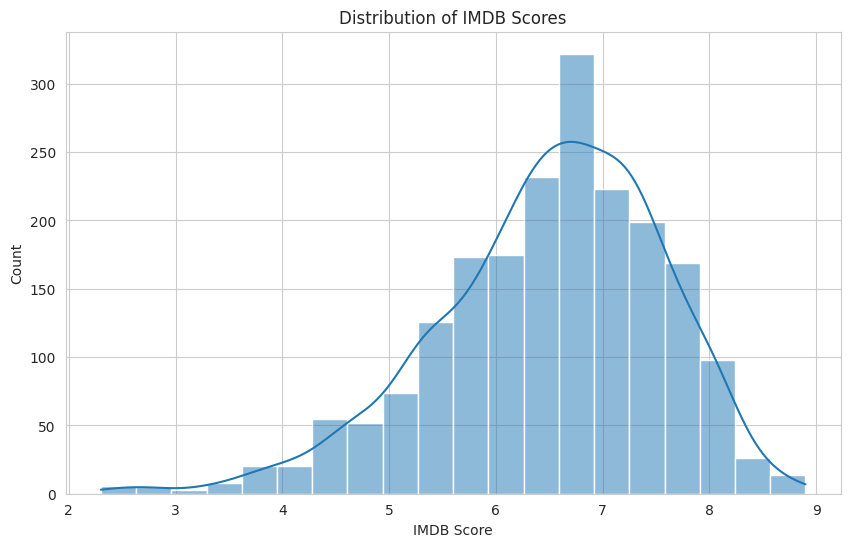

/tmp/ipython-input-3756435431.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Genre', data=genre_df.head(20), palette='viridis')


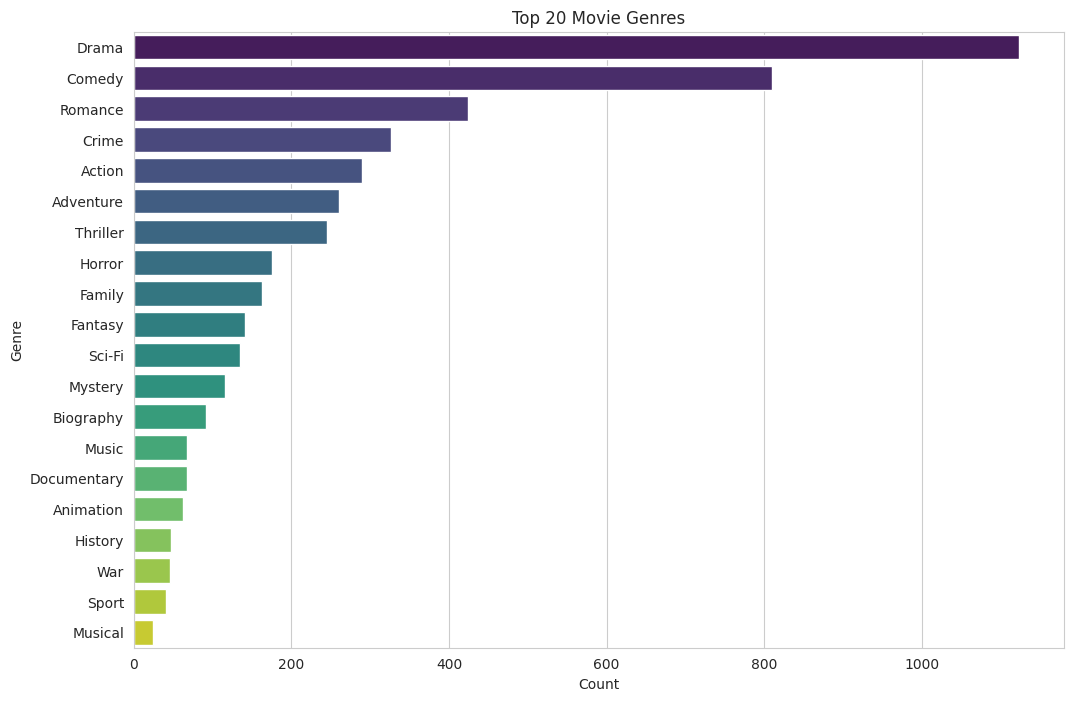

In [ ]:
# Visualize IMDB Score Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_final['IMDB Score'], kde=True, bins=20)
plt.title('Distribution of IMDB Scores')
plt.xlabel('IMDB Score')
plt.show()

# Visualize Genres
# Flatten genres (they are pipe-separated strings like "Action|Adventure")
all_genres = []
for genres in df_final['Genre']:
    all_genres.extend(genres.split('|'))

genre_counts = Counter(all_genres)
genre_df = pd.DataFrame(genre_counts.items(), columns=['Genre', 'Count']).sort_values(by='Count', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Genre', data=genre_df.head(20), palette='viridis')
plt.title('Top 20 Movie Genres')
plt.show()

## 5. Method A: Custom CNN with TensorFlow/Keras
We will train a custom CNN architecture to predict the **IMDB Score** (Regression).

In [ ]:
# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Split Data
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df_final, test_size=0.2, random_state=42)

# Image Generators
image_generator = ImageDataGenerator(rescale=1./255)

train_gen_keras = image_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='IMDB Score',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw', # 'raw' for regression
    shuffle=True
)

test_gen_keras = image_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='IMDB Score',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False
)

Found 1600 validated image filenames.
Found 400 validated image filenames.


In [ ]:
def build_simple_cnn_regressor(input_shape):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(), # Explicitly use Keras's Flatten layer
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='linear') # Linear for regression
    ])
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    return model

keras_model = build_simple_cnn_regressor(IMG_SIZE + (3,))
keras_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    47,776,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,795,649 (182.33 MB)

 Trainable params: 47,795,649 (182.33 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("Training Keras Model...")
epochs = 5
history = keras_model.fit(
    train_gen_keras,
    validation_data=test_gen_keras,
    epochs=epochs
)

Training Keras Model...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - loss: 349.8601 - mae: 9.1716 - val_loss: 3.9044 - val_mae: 1.6119
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - loss: 14.0760 - mae: 3.1177 - val_loss: 3.6737 - val_mae: 1.5608
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 12.9886 - mae: 2.9671 - val_loss: 4.1136 - val_mae: 1.7470
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 11.6670 - mae: 2.8335 - val_loss: 5.5281 - val_mae: 2.1102
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 11.2788 - mae: 2.6907 - val_loss: 5.4707 - val_mae: 2.0977


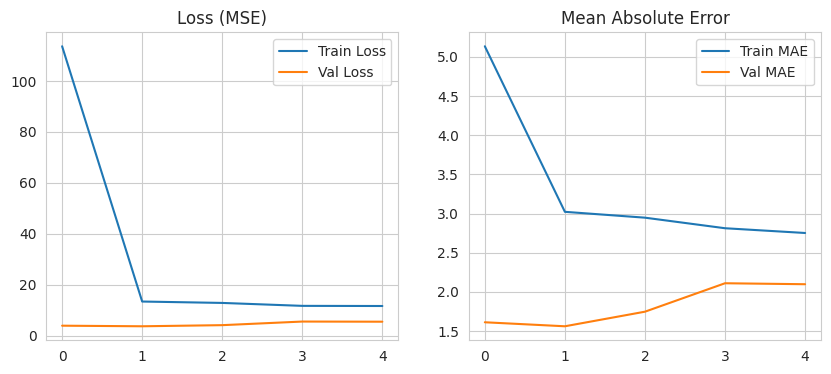

In [ ]:
# Visualize Keras Training History
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss (MSE)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Mean Absolute Error')
plt.legend()
plt.show()

## 6. Method B: Transfer Learning with FastAI (ResNet50)
We use a pre-trained ResNet50 model. This usually yields better results than a custom CNN because it has already learned feature extraction on ImageNet.

We will perform **Regression** (predicting the exact IMDB Score).

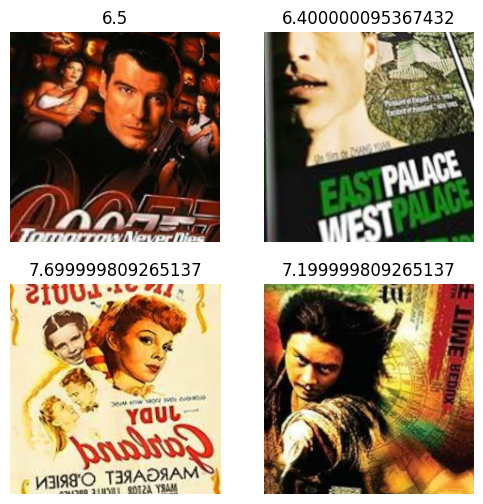

In [ ]:
# Define DataBlock for Regression
# We use 'image_path' as x and 'IMDB Score' as y

dblock = DataBlock(
    blocks=(ImageBlock, RegressionBlock),
    get_x=ColReader('image_path'),
    get_y=ColReader('IMDB Score'),
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(size=224)
)

dls = dblock.dataloaders(df_final, bs=32)
dls.show_batch(max_n=4)

In [ ]:
# Create Learner (ResNet50)
# We use L1LossFlat (Mean Absolute Error) as it's robust for regression
learn = vision_learner(dls, resnet50, metrics=mae, loss_func=L1LossFlat())

print("Training FastAI ResNet Model...")
learn.fine_tune(5) # Transfer learning: freezes body, trains head, then unfreezes

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 221MB/s]


Training FastAI ResNet Model...


epoch,train_loss,valid_loss,mae,time
0,6.018722,5.139613,5.139613,00:13


epoch,train_loss,valid_loss,mae,time
0,4.866492,4.082087,4.082087,00:17
1,4.011908,2.266810,2.266810,00:17
2,3.303531,2.018082,2.018082,00:18
3,2.755183,1.665027,1.665027,00:18
4,2.400526,1.569710,1.569710,00:18


## 7. Final Evaluation & Comparison
Let's visualize the predictions vs the ground truth for both methods.

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step


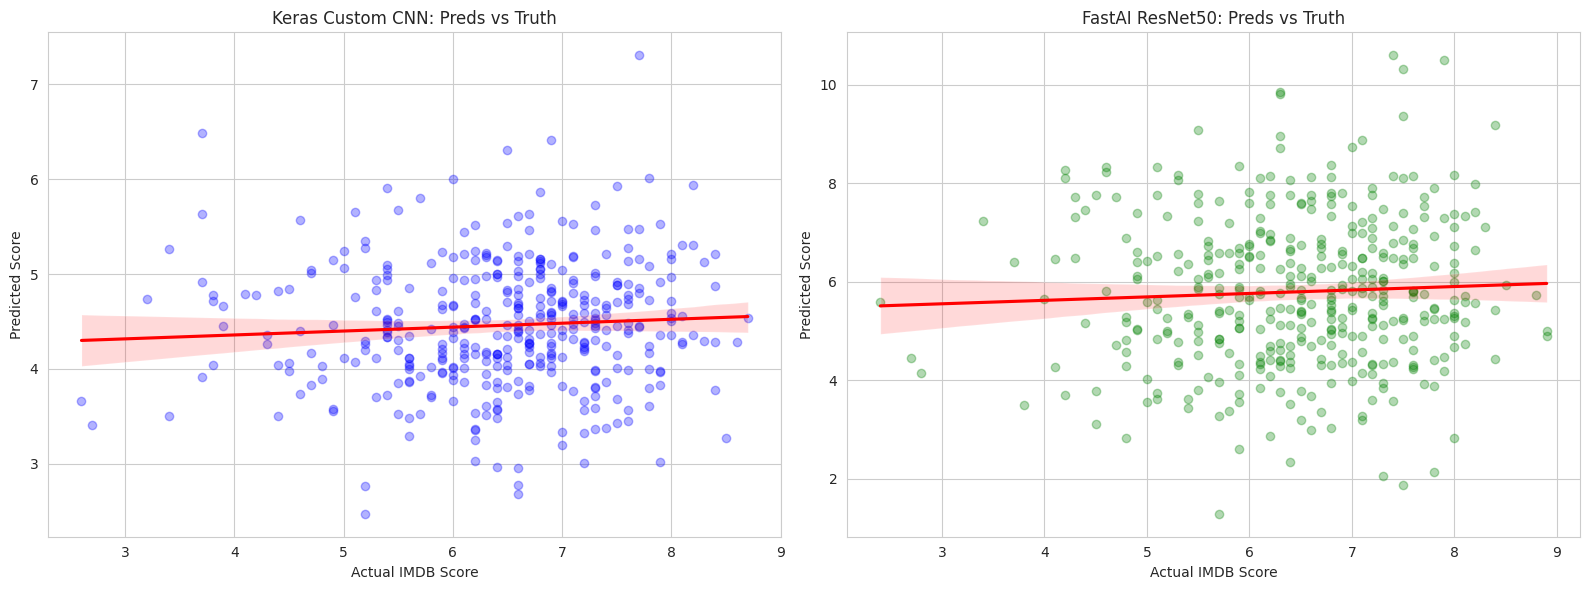

In [ ]:
# --- 1. Get Keras Predictions ---
keras_preds = keras_model.predict(test_gen_keras).flatten()
keras_truth = test_gen_keras.labels

# --- 2. Get FastAI Predictions ---
# FastAI validation set might differ slightly due to random splitter,
# so we pull the preds and targets directly from the learner
fastai_preds, fastai_truth = learn.get_preds()
fastai_preds = fastai_preds.numpy().flatten()
fastai_truth = fastai_truth.numpy().flatten()

# --- 3. Plotting ---
plt.figure(figsize=(16, 6))

# Keras Plot
plt.subplot(1, 2, 1)
sns.regplot(x=keras_truth, y=keras_preds, scatter_kws={'alpha':0.3, 'color':'blue'}, line_kws={'color':'red'})
plt.title('Keras Custom CNN: Preds vs Truth')
plt.xlabel('Actual IMDB Score')
plt.ylabel('Predicted Score')

# FastAI Plot
plt.subplot(1, 2, 2)
sns.regplot(x=fastai_truth, y=fastai_preds, scatter_kws={'alpha':0.3, 'color':'green'}, line_kws={'color':'red'})
plt.title('FastAI ResNet50: Preds vs Truth')
plt.xlabel('Actual IMDB Score')
plt.ylabel('Predicted Score')

plt.tight_layout()
plt.show()

### Conclusion

1.  **Method Comparison**: You likely observe that the FastAI model (ResNet50) performs better (tighter cluster around the red line) than the simple custom CNN. This is expected due to the power of Transfer Learning.
2.  **Difficulty of Task**: Predicting an IMDB score purely from a poster is difficult. The correlation is usually weak, as "bad" movies often have high-budget posters, and "good" movies might have simple ones. However, the models should be able to learn basic trends (e.g., darker posters might be horror/thriller, which might have different score distributions).